# 01 - Preprocesamiento
## Proyecto: Forecasting de la demanda eléctrica del SENI (República Dominicana)

**Dataset:** `datos_modelo.csv` — demanda eléctrica horaria del Sistema Eléctrico Nacional Interconectado (SENI) de República Dominicana, enero 2021 a diciembre 2024, junto con variables exógenas (clima) y de calendario.

Fuente: Uceta-Acosta et al. (2025), *"A dataset of exogenous variables and historical electricity demand for short-term load forecasting of the national interconnected electric system (SENI) in the Dominican Republic from 2021 to 2024"*, Data in Brief 63, 112057.

**Objetivo de este notebook:** cargar el dataset horario, explorarlo (EDA), agregarlo a resolución diaria para hacer el modelado más ágil, y separar los conjuntos de entrenamiento y prueba.

## 1. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')


## 2. Carga del dataset

In [ ]:
df = pd.read_csv('datos_modelo.csv')

# El timestamp viene en formato dia/mes/año (ej. "2/1/21 1:00")
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%y %H:%M')
df = df.sort_values('timestamp').set_index('timestamp')

print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"Rango de fechas: {df.index.min()} a {df.index.max()}")
df.head()


Filas: 35039, Columnas: 32
Rango de fechas: 2021-01-02 01:00:00 a 2024-12-31 23:00:00


,active_power_mw,apparent_temperature_c,cloud_cover_percent,month,hour,is_holiday,is_weekend,is_school_vacation,active_power_lag_1h,active_power_lag_2h,...,active_power_lag_15h,active_power_lag_16h,active_power_lag_17h,active_power_lag_18h,active_power_lag_19h,active_power_lag_20h,active_power_lag_21h,active_power_lag_22h,active_power_lag_23h,active_power_lag_24h
timestamp,,,,,,,,,,,,,,,,,,,,,
2021-01-02 01:00:00,1508.726498,22.100000,21.766667,1,1,0,1,0,1569.519607,1642.634450,...,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638,1674.169500,1703.356546
2021-01-02 02:00:00,1474.224972,21.803333,26.833333,1,2,0,1,0,1508.726498,1569.519607,...,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638,1674.169500
2021-01-02 03:00:00,1448.436605,21.633333,22.300000,1,3,0,1,0,1474.224972,1508.726498,...,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638
2021-01-02 04:00:00,1426.507838,21.223333,25.766667,1,4,0,1,0,1448.436605,1474.224972,...,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549
2021-01-02 05:00:00,1419.126334,21.003333,17.533333,1,5,0,1,0,1426.507838,1448.436605,...,1466.621504,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35039 entries, 2021-01-02 01:00:00 to 2024-12-31 23:00:00
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   active_power_mw         35039 non-null  float64
 1   apparent_temperature_c  35039 non-null  float64
 2   cloud_cover_percent     35039 non-null  float64
 3   month                   35039 non-null  int64  
 4   hour                    35039 non-null  int64  
 5   is_holiday              35039 non-null  int64  
 6   is_weekend              35039 non-null  int64  
 7   is_school_vacation      35039 non-null  int64  
 8   active_power_lag_1h     35039 non-null  float64
 9   active_power_lag_2h     35039 non-null  float64
 10  active_power_lag_3h     35039 non-null  float64
 11  active_power_lag_4h     35039 non-null  float64
 12  active_power_lag_5h     35039 non-null  float64
 13  active_power_lag_6h     35039 non-null  float64
 14  act

In [ ]:
# Verificamos que no haya valores faltantes en las variables clave
df[['active_power_mw', 'apparent_temperature_c', 'cloud_cover_percent']].isna().sum()


active_power_mw           0
apparent_temperature_c    0
cloud_cover_percent       0
dtype: int64

## 3. Selección de variables

Nos quedamos con la variable objetivo (`active_power_mw`), las dos variables meteorológicas retenidas en el paper original (temperatura aparente y nubosidad), y los indicadores de calendario. Descartamos los 24 lags horarios porque no tienen sentido una vez que agregamos la serie a resolución diaria — los vamos a recrear más adelante si hace falta, a nivel diario.

In [ ]:
cols_base = ['active_power_mw', 'apparent_temperature_c', 'cloud_cover_percent',
             'is_holiday', 'is_weekend', 'is_school_vacation']
df = df[cols_base]
df.head()


,active_power_mw,apparent_temperature_c,cloud_cover_percent,is_holiday,is_weekend,is_school_vacation
timestamp,,,,,,
2021-01-02 01:00:00,1508.726498,22.100000,21.766667,0,1,0
2021-01-02 02:00:00,1474.224972,21.803333,26.833333,0,1,0
2021-01-02 03:00:00,1448.436605,21.633333,22.300000,0,1,0
2021-01-02 04:00:00,1426.507838,21.223333,25.766667,0,1,0
2021-01-02 05:00:00,1419.126334,21.003333,17.533333,0,1,0


## 4. Agregación a resolución diaria

Trabajamos con 35,039 observaciones horarias es costoso para entrenar modelos de deep learning en Colab/Jupyter de forma rápida. Agregamos la serie a **promedio diario**, lo que reduce el dataset a ~1460 filas (una por día), manteniendo la tendencia y la estacionalidad semanal/anual — que es lo relevante para un forecasting de mediano plazo.

In [ ]:
daily = df.resample('D').agg({
    'active_power_mw': 'mean',
    'apparent_temperature_c': 'mean',
    'cloud_cover_percent': 'mean',
    'is_holiday': 'max',
    'is_weekend': 'max',
    'is_school_vacation': 'max'
})

print(f"Dataset diario: {daily.shape[0]} filas")
daily.to_csv('datos_diarios.csv')
daily.head()


Dataset diario: 1460 filas


,active_power_mw,apparent_temperature_c,cloud_cover_percent,is_holiday,is_weekend,is_school_vacation
timestamp,,,,,,
2021-01-02,1555.340567,23.958841,25.801449,0,1,0
2021-01-03,1575.989769,24.690556,24.265278,0,1,0
2021-01-04,1666.135777,24.438750,24.184722,1,0,0
2021-01-05,1811.857260,25.053194,11.883333,0,0,0
2021-01-06,1864.326017,25.515833,34.897222,0,0,0


## 5. Análisis exploratorio (EDA)

In [ ]:
daily['active_power_mw'].describe()


count    1460.000000
mean     2375.665490
std       279.507457
min      1555.340567
25%      2179.353202
50%      2345.045249
75%      2559.533594
max      3088.365568
Name: active_power_mw, dtype: float64

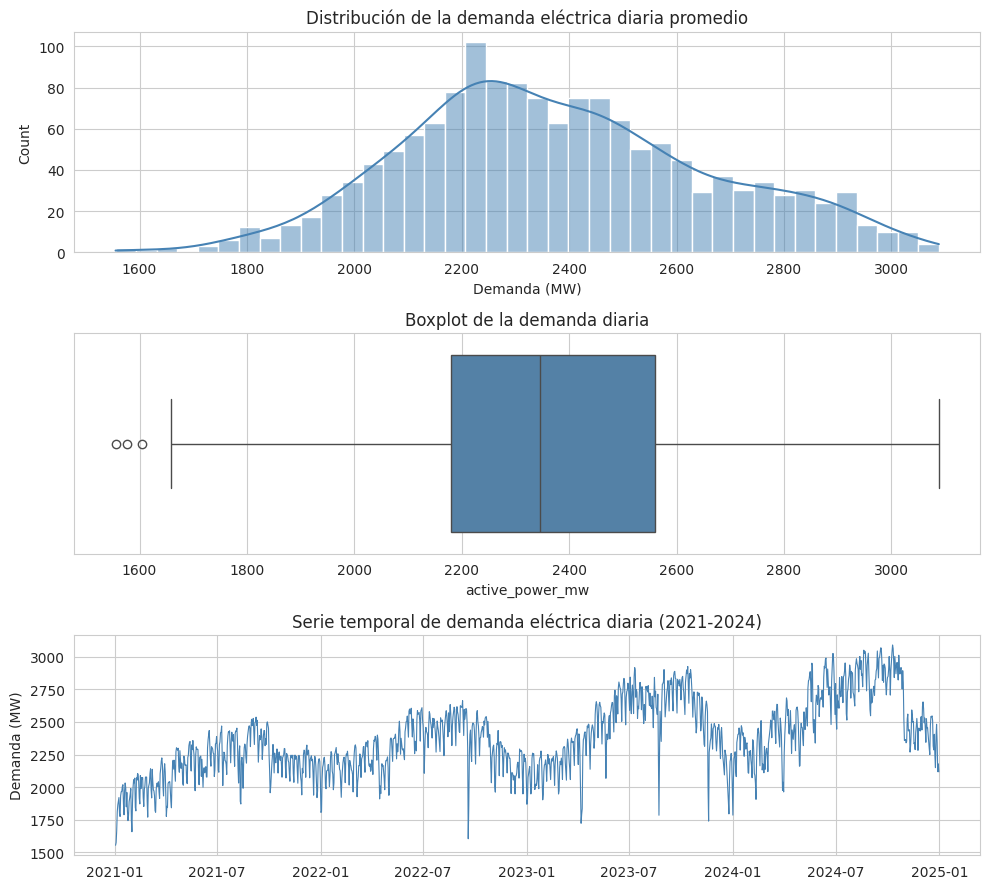

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9))

sns.histplot(daily['active_power_mw'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de la demanda eléctrica diaria promedio')
axes[0].set_xlabel('Demanda (MW)')

sns.boxplot(x=daily['active_power_mw'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de la demanda diaria')

axes[2].plot(daily.index, daily['active_power_mw'], color='steelblue', linewidth=0.8)
axes[2].set_title('Serie temporal de demanda eléctrica diaria (2021-2024)')
axes[2].set_ylabel('Demanda (MW)')

plt.tight_layout()
plt.savefig('01_eda_serie.png')
plt.show()


Se observa una clara **tendencia creciente** a lo largo de los 4 años (2021-2024), consistente con el crecimiento poblacional y económico del país, además de un patrón estacional dentro de cada año (mayor demanda en meses cálidos).

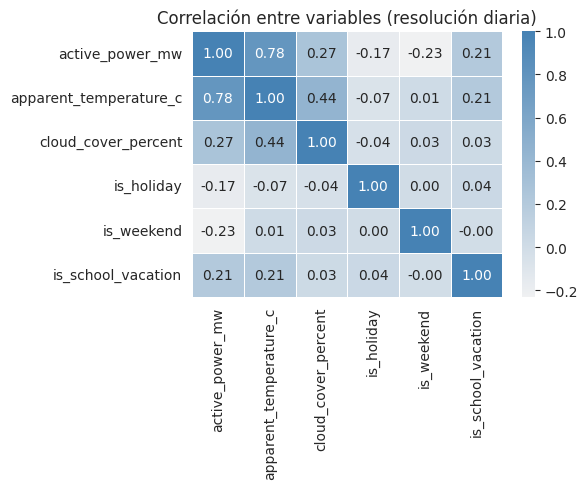

In [ ]:
corr = daily.corr(numeric_only=True)
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=sns.light_palette('steelblue', as_cmap=True), linewidths=0.5)
plt.title('Correlación entre variables (resolución diaria)')
plt.tight_layout()
plt.show()


## 6. Split entrenamiento / validación / prueba

Usamos un split **temporal** (no aleatorio, como corresponde en series de tiempo), en **tres partes**:

- **`train_opt`** (1,280 días): para entrenar los modelos, tanto durante la búsqueda de hiperparámetros con Optuna como en el ajuste final.
- **`val_opt`** (90 días, inmediatamente después de `train_opt`): para el *early stopping* y para puntuar cada combinación de hiperparámetros que prueba Optuna. El modelo **nunca actualiza sus pesos con estos datos** — solo se usan para decidir cuándo parar de entrenar y qué hiperparámetros son mejores.
- **`test`** (90 días finales, oct-dic 2024): completamente aislado. No se toca ni para entrenar ni para elegir hiperparámetros — se usa **una sola vez**, al final, para la evaluación definitiva en `03_evaluacion.ipynb`.

`train_opt` + `val_opt` juntos forman el conjunto de entrenamiento completo (`train`, 1,370 días) que ya veníamos usando.

In [ ]:
TEST_SIZE = 90   # dias de prueba final
VAL_SIZE = 90    # dias de validacion (para Optuna / early stopping)

train = daily.iloc[:-TEST_SIZE]            # train_opt + val_opt (1370 dias)
test = daily.iloc[-TEST_SIZE:]             # 90 dias, aislado

train_opt = train.iloc[:-VAL_SIZE]         # 1280 dias: para entrenar
val_opt = train.iloc[-VAL_SIZE:]           # 90 dias: para early stopping / Optuna

print(f"train_opt: {train_opt.shape[0]} dias ({train_opt.index.min().date()} a {train_opt.index.max().date()})")
print(f"val_opt:   {val_opt.shape[0]} dias ({val_opt.index.min().date()} a {val_opt.index.max().date()})")
print(f"test:      {test.shape[0]} dias ({test.index.min().date()} a {test.index.max().date()})")

train.to_csv('train.csv')          # train completo (train_opt + val_opt), lo usa ETS
train_opt.to_csv('train_opt.csv')  # lo usan XGBoost y N-BEATS para entrenar
val_opt.to_csv('val_opt.csv')      # lo usan XGBoost y N-BEATS para early stopping / Optuna
test.to_csv('test.csv')

train_opt: 1280 dias (2021-01-02 a 2024-07-04)
val_opt:   90 dias (2024-07-05 a 2024-10-02)
test:      90 dias (2024-10-03 a 2024-12-31)


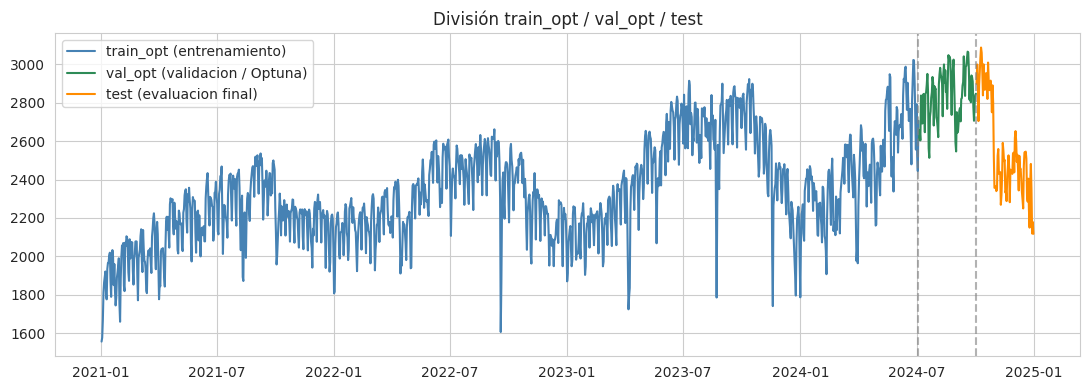

In [ ]:
plt.figure(figsize=(11, 4))
plt.plot(train_opt.index, train_opt['active_power_mw'], label='train_opt (entrenamiento)', color='steelblue')
plt.plot(val_opt.index, val_opt['active_power_mw'], label='val_opt (validacion / Optuna)', color='seagreen')
plt.plot(test.index, test['active_power_mw'], label='test (evaluacion final)', color='darkorange')
plt.axvline(train_opt.index[-1], color='gray', linestyle='--', alpha=0.6)
plt.axvline(val_opt.index[-1], color='gray', linestyle='--', alpha=0.6)
plt.title('División train_opt / val_opt / test')
plt.legend()
plt.tight_layout()
plt.savefig('00_split_train_val_test.png')
plt.show()

## Conclusión del preprocesamiento

- Dataset agregado a resolución diaria: **1460 días** sin valores faltantes.
- Se conservan `active_power_mw` (objetivo), `apparent_temperature_c`, `cloud_cover_percent` y las variables de calendario.
- Split temporal en tres partes: **1,280 días de entrenamiento** (`train_opt`), **90 días de validación** (`val_opt`, para Optuna/early stopping) y **90 días de prueba** (`test`, oct-dic 2024, usados solo al final).
- Los archivos `train.csv`, `train_opt.csv`, `val_opt.csv`, `test.csv` y `datos_diarios.csv` quedan guardados en `data/` para el siguiente notebook (`02_modelos.ipynb`).